In [5]:
import numpy as np
from scipy.optimize import least_squares
from scipy.special import erf

In [6]:
def generate_background(shape, background_level, noise_sigma=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    image = np.full(shape, background_level, dtype=float)
    if noise_sigma > 0:
        image += rng.normal(0.0, noise_sigma, size=shape)
    return image


def generate_trail(shape, flux, x0, y0, length, theta, sigma, background=0.0):
    ny, nx = shape
    y, x = np.mgrid[0:ny, 0:nx]
    xp = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
    yp = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    prefactor = flux / (length * 2.0 * sigma * np.sqrt(2.0 * np.pi))
    cross_trail = np.exp(-(yp ** 2) / (2.0 * sigma ** 2))
    u1 = (xp + length / 2.0) / (sigma * np.sqrt(2.0))
    u2 = (xp - length / 2.0) / (sigma * np.sqrt(2.0))
    along_trail = erf(u1) - erf(u2)
    return background + prefactor * cross_trail * along_trail


def fit_trail(image, p0, bounds=None):
    ny, nx = image.shape

    def residuals(params):
        flux, x0, y0, length, theta, sigma, background = params
        if length <= 0 or sigma <= 0 or flux < 0:
            return np.full(image.size, 1e30)
        model = generate_trail(image.shape, flux, x0, y0, length, theta, sigma, background)
        return (model - image).ravel()

    if bounds is None:
        lower = [0.0, 0.0, 0.0, 1e-6, -np.pi, 1e-3, -np.inf]
        upper = [np.inf, nx, ny, max(nx, ny), np.pi, np.inf, np.inf]
        bounds = (lower, upper)

    result = least_squares(residuals, p0, bounds=bounds)
    best_fit = {"flux": result.x[0], "x0": result.x[1], "y0": result.x[2], "length": result.x[3], "theta": result.x[4], "sigma": result.x[5], "background": result.x[6]}
    model = generate_trail(image.shape, best_fit["flux"], best_fit["x0"], best_fit["y0"], best_fit["length"], best_fit["theta"], best_fit["sigma"], best_fit["background"])
    return result, best_fit, model

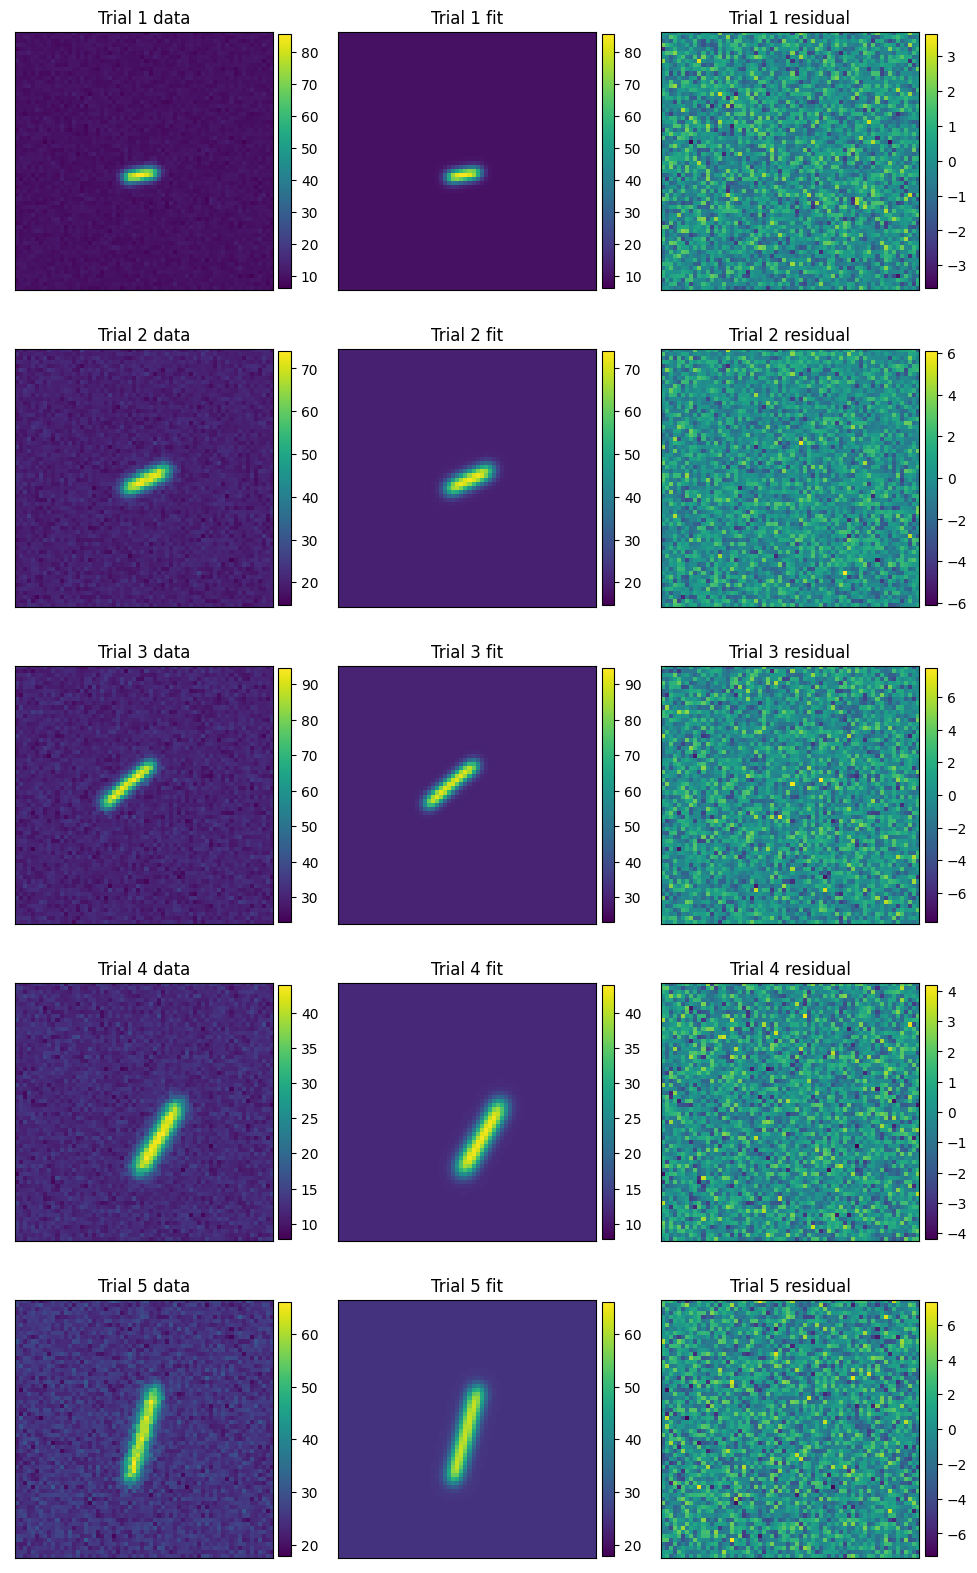

Trial  1: success=True  flux 1800.0->1795.4  x0 30.50->30.52  y0 28.00->28.00  L 8.00->7.98  theta_deg 10.00->9.89  sigma 1.20->1.20  bg 10.00->9.99
Trial  2: success=True  flux 2400.0->2365.9  x0 32.00->31.96  y0 31.00->30.99  L 12.00->11.93  theta_deg 25.00->25.14  sigma 1.50->1.48  bg 20.00->19.98
Trial  3: success=True  flux 3200.0->3165.0  x0 27.50->27.48  y0 34.00->33.99  L 16.00->15.99  theta_deg 40.00->39.88  sigma 1.30->1.28  bg 30.00->30.00
Trial  4: success=True  flux 2800.0->2832.2  x0 35.00->35.00  y0 25.00->25.00  L 20.00->19.92  theta_deg 60.00->59.92  sigma 1.80->1.80  bg 12.00->12.00
Trial  5: success=True  flux 3600.0->3594.0  x0 31.00->31.02  y0 30.00->29.99  L 24.00->23.97  theta_deg 75.00->74.83  sigma 1.60->1.61  bg 25.00->24.98
Trial  6: success=True  flux 2200.0->2199.0  x0 26.00->25.98  y0 27.50->27.50  L 10.00->9.94  theta_deg 95.00->95.25  sigma 1.40->1.40  bg 15.00->15.00
Trial  7: success=True  flux 3000.0->2993.3  x0 29.00->28.99  y0 32.50->32.53  L 14.00-

In [10]:
rng = np.random.default_rng(7)
shape = (64, 64)

trial_params = [
    {"flux": 1800.0, "x0": 30.5, "y0": 28.0, "length": 8.0,  "theta": np.deg2rad(10.0),  "sigma": 1.2, "background": 10.0, "noise_sigma": 1.0},
    {"flux": 2400.0, "x0": 32.0, "y0": 31.0, "length": 12.0, "theta": np.deg2rad(25.0),  "sigma": 1.5, "background": 20.0, "noise_sigma": 1.5},
    {"flux": 3200.0, "x0": 27.5, "y0": 34.0, "length": 16.0, "theta": np.deg2rad(40.0),  "sigma": 1.3, "background": 30.0, "noise_sigma": 2.0},
    {"flux": 2800.0, "x0": 35.0, "y0": 25.0, "length": 20.0, "theta": np.deg2rad(60.0),  "sigma": 1.8, "background": 12.0, "noise_sigma": 1.2},
    {"flux": 3600.0, "x0": 31.0, "y0": 30.0, "length": 24.0, "theta": np.deg2rad(75.0),  "sigma": 1.6, "background": 25.0, "noise_sigma": 2.2},
    {"flux": 2200.0, "x0": 26.0, "y0": 27.5, "length": 10.0, "theta": np.deg2rad(95.0),  "sigma": 1.4, "background": 15.0, "noise_sigma": 1.0},
    {"flux": 3000.0, "x0": 29.0, "y0": 32.5, "length": 14.0, "theta": np.deg2rad(115.0), "sigma": 1.7, "background": 35.0, "noise_sigma": 2.5},
    {"flux": 4200.0, "x0": 33.0, "y0": 29.0, "length": 18.0, "theta": np.deg2rad(135.0), "sigma": 1.5, "background": 18.0, "noise_sigma": 1.8},
    {"flux": 2600.0, "x0": 30.0, "y0": 35.0, "length": 22.0, "theta": np.deg2rad(150.0), "sigma": 1.9, "background": 28.0, "noise_sigma": 2.0},
    {"flux": 3400.0, "x0": 34.0, "y0": 27.0, "length": 26.0, "theta": np.deg2rad(170.0), "sigma": 1.6, "background": 22.0, "noise_sigma": 1.6},
]

results = []
for p in trial_params:
    image = generate_background(shape, p["background"], p["noise_sigma"], rng=rng)
    image += generate_trail(shape, p["flux"], p["x0"], p["y0"], p["length"], p["theta"], p["sigma"], 0.0)
    p0 = [0.8 * p["flux"], p["x0"] + rng.normal(0.0, 1.0), p["y0"] + rng.normal(0.0, 1.0), max(1.0, 0.8 * p["length"]), p["theta"] + rng.normal(0.0, np.deg2rad(8.0)), max(0.8, 1.2 * p["sigma"]), max(0.0, p["background"] + rng.normal(0.0, 3.0))]
    result, best_fit, model = fit_trail(image, p0)
    results.append({"truth": p, "image": image, "fit": model, "resid": image - model, "best_fit": best_fit, "success": result.success, "cost": result.cost})

fig, axes = plt.subplots(5, 3, figsize=(10, 16))
for i in range(5):
    data = results[i]["image"]
    fit = results[i]["fit"]
    resid = results[i]["resid"]
    vmin = min(np.min(data), np.min(fit))
    vmax = max(np.max(data), np.max(fit))
    rmax = np.max(np.abs(resid))

    ax = axes[i, 0]
    im = ax.imshow(data, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(f"Trial {i + 1} data")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    ax = axes[i, 1]
    im = ax.imshow(fit, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(f"Trial {i + 1} fit")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    ax = axes[i, 2]
    im = ax.imshow(resid, origin="lower", vmin=-rmax, vmax=rmax)
    ax.set_title(f"Trial {i + 1} residual")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.tight_layout()
plt.show()

for i, r in enumerate(results, start=1):
    t = r["truth"]
    b = r["best_fit"]
    print(f"Trial {i:2d}: success={r['success']}  "
    f"flux {t['flux']:.1f}->{b['flux']:.1f}  "
    f"x0 {t['x0']:.2f}->{b['x0']:.2f}  "
    f"y0 {t['y0']:.2f}->{b['y0']:.2f}  "
    f"L {t['length']:.2f}->{b['length']:.2f}  "
    f"theta_deg {np.rad2deg(t['theta']):.2f}->{np.rad2deg(b['theta']):.2f}  "
    f"sigma {t['sigma']:.2f}->{b['sigma']:.2f}  "
    f"bg {t['background']:.2f}->{b['background']:.2f}")

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


def generate_star(shape, flux, x0, y0, sigma):
    ny, nx = shape
    y, x = np.mgrid[0:ny, 0:nx]
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    return flux * np.exp(-r2 / (2.0 * sigma ** 2)) / (2.0 * np.pi * sigma ** 2)


def generate_trail_star_image(shape, trail_params, star_params, background, noise_sigma=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    image = generate_background(shape, background, noise_sigma, rng=rng)
    image += generate_trail(shape, trail_params["flux"], trail_params["x0"], trail_params["y0"], trail_params["length"], trail_params["theta"], trail_params["sigma"], 0.0)
    image += generate_star(shape, star_params["flux"], star_params["x0"], star_params["y0"], star_params["sigma"])
    return image


def fit_trail_plus_star(image, p0, bounds=None):
    ny, nx = image.shape

    def model_from_params(params):
        trail_flux, trail_x0, trail_y0, trail_length, trail_theta, trail_sigma, star_flux, star_x0, star_y0, star_sigma, background = params
        trail = generate_trail(image.shape, trail_flux, trail_x0, trail_y0, trail_length, trail_theta, trail_sigma, 0.0)
        star = generate_star(image.shape, star_flux, star_x0, star_y0, star_sigma)
        return trail + star + background

    def residuals(params):
        trail_flux, trail_x0, trail_y0, trail_length, trail_theta, trail_sigma, star_flux, star_x0, star_y0, star_sigma, background = params
        if trail_flux < 0 or trail_length <= 0 or trail_sigma <= 0 or star_flux < 0 or star_sigma <= 0:
            return np.full(image.size, 1e30)
        model = model_from_params(params)
        return (model - image).ravel()

    if bounds is None:
        lower = [0.0, 0.0, 0.0, 1e-6, -np.pi, 1e-3, 0.0, 0.0, 0.0, 1e-3, -np.inf]
        upper = [np.inf, nx, ny, max(nx, ny), np.pi, np.inf, np.inf, nx, ny, np.inf, np.inf]
        bounds = (lower, upper)

    result = least_squares(residuals, p0, bounds=bounds)
    best = {"trail_flux": result.x[0], "trail_x0": result.x[1], "trail_y0": result.x[2], "trail_length": result.x[3], "trail_theta": result.x[4], "trail_sigma": result.x[5], "star_flux": result.x[6], "star_x0": result.x[7], "star_y0": result.x[8], "star_sigma": result.x[9], "background": result.x[10]}
    model = model_from_params(result.x)
    return result, best, model

trail_flux 2600.0->2624.4  trail_x0 28.50->28.47  trail_y0 31.00->30.99  trail_L 18.00->17.92  trail_theta_deg 35.00->34.89  trail_sigma 1.50->1.52
star_flux 1400.0->1395.5  star_x0 36.00->36.00  star_y0 33.00->33.01  star_sigma 1.40->1.40  bg 18.00->18.00


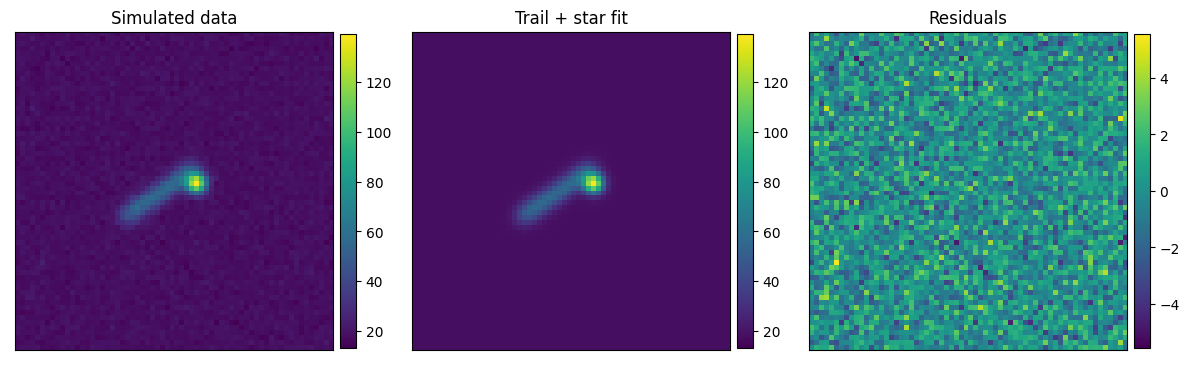

In [16]:
rng = np.random.default_rng(12)
shape = (64, 64)

trail_true = {"flux": 2600.0, "x0": 28.5, "y0": 31.0, "length": 18.0, "theta": np.deg2rad(35.0), "sigma": 1.5}
star_true = {"flux": 1400.0, "x0": 36.0, "y0": 33.0, "sigma": 1.4}
background_true = 18.0
noise_sigma = 1.5

image = generate_trail_star_image(shape, trail_true, star_true, background_true, noise_sigma=noise_sigma, rng=rng)

p0 = [2000.0, 27.5, 30.5, 15.0, np.deg2rad(30.0), 1.7,1200.0, 35.0, 34.0, 1.6,16.0]

result, best, model = fit_trail_plus_star(image, p0)
resid = image - model

print(
    f"trail_flux {trail_true['flux']:.1f}->{best['trail_flux']:.1f}  "
    f"trail_x0 {trail_true['x0']:.2f}->{best['trail_x0']:.2f}  "
    f"trail_y0 {trail_true['y0']:.2f}->{best['trail_y0']:.2f}  "
    f"trail_L {trail_true['length']:.2f}->{best['trail_length']:.2f}  "
    f"trail_theta_deg {np.rad2deg(trail_true['theta']):.2f}->{np.rad2deg(best['trail_theta']):.2f}  "
    f"trail_sigma {trail_true['sigma']:.2f}->{best['trail_sigma']:.2f}"
)

print(
    f"star_flux {star_true['flux']:.1f}->{best['star_flux']:.1f}  "
    f"star_x0 {star_true['x0']:.2f}->{best['star_x0']:.2f}  "
    f"star_y0 {star_true['y0']:.2f}->{best['star_y0']:.2f}  "
    f"star_sigma {star_true['sigma']:.2f}->{best['star_sigma']:.2f}  "
    f"bg {background_true:.2f}->{best['background']:.2f}"
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

vmin = min(np.min(image), np.min(model))
vmax = max(np.max(image), np.max(model))
rmax = np.max(np.abs(resid))

im = axes[0].imshow(image, origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("Simulated data")
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.02)

im = axes[1].imshow(model, origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("Trail + star fit")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.02)

im = axes[2].imshow(resid, origin="lower", vmin=-rmax, vmax=rmax)
axes[2].set_title("Residuals")
axes[2].set_xticks([])
axes[2].set_yticks([])
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.02)

plt.tight_layout()
plt.show()

trail_flux 2600.0->1839.8  trail_x0 28.50->26.51  trail_y0 31.00->29.71  trail_L 18.00->7.22  trail_theta_deg 35.00->180.00  trail_sigma 1.50->2.56
star_flux 1400.0->2160.3  star_x0 36.00->35.49  star_y0 33.00->33.39  star_sigma 1.40->1.78  bg 18.00->18.01


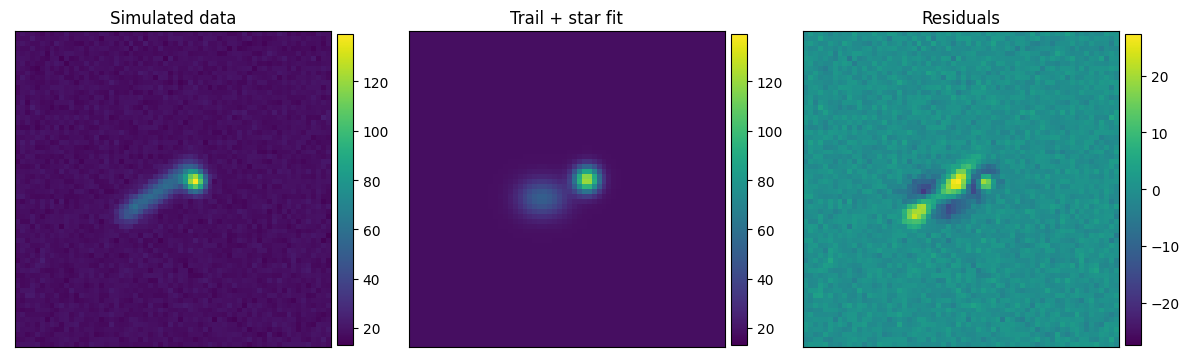

In [18]:
rng = np.random.default_rng(12)
shape = (64, 64)

trail_true = {"flux": 2600.0, "x0": 28.5, "y0": 31.0, "length": 18.0, "theta": np.deg2rad(35.0), "sigma": 1.5}
star_true = {"flux": 1400.0, "x0": 36.0, "y0": 33.0, "sigma": 1.4}
background_true = 18.0
noise_sigma = 1.5

image = generate_trail_star_image(shape, trail_true, star_true, background_true, noise_sigma=noise_sigma, rng=rng)

p0 = [200.0, 27.5, 30.5, 15.0, np.deg2rad(30.0), 1.7,1200.0, 35.0, 34.0, 1.6,16.0]

result, best, model = fit_trail_plus_star(image, p0)
resid = image - model

print(
    f"trail_flux {trail_true['flux']:.1f}->{best['trail_flux']:.1f}  "
    f"trail_x0 {trail_true['x0']:.2f}->{best['trail_x0']:.2f}  "
    f"trail_y0 {trail_true['y0']:.2f}->{best['trail_y0']:.2f}  "
    f"trail_L {trail_true['length']:.2f}->{best['trail_length']:.2f}  "
    f"trail_theta_deg {np.rad2deg(trail_true['theta']):.2f}->{np.rad2deg(best['trail_theta']):.2f}  "
    f"trail_sigma {trail_true['sigma']:.2f}->{best['trail_sigma']:.2f}"
)

print(
    f"star_flux {star_true['flux']:.1f}->{best['star_flux']:.1f}  "
    f"star_x0 {star_true['x0']:.2f}->{best['star_x0']:.2f}  "
    f"star_y0 {star_true['y0']:.2f}->{best['star_y0']:.2f}  "
    f"star_sigma {star_true['sigma']:.2f}->{best['star_sigma']:.2f}  "
    f"bg {background_true:.2f}->{best['background']:.2f}"
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

vmin = min(np.min(image), np.min(model))
vmax = max(np.max(image), np.max(model))
rmax = np.max(np.abs(resid))

im = axes[0].imshow(image, origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("Simulated data")
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.02)

im = axes[1].imshow(model, origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("Trail + star fit")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.02)

im = axes[2].imshow(resid, origin="lower", vmin=-rmax, vmax=rmax)
axes[2].set_title("Residuals")
axes[2].set_xticks([])
axes[2].set_yticks([])
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.02)

plt.tight_layout()
plt.show()